In [2]:
from os import chdir
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

cwd = Path.cwd()
print(f"CWD: {cwd}")
if cwd.name == "code":
    chdir("..")
print(f"CWD: {Path.cwd()}")

CWD: /Users/haowen/Documents/Decentral RS/fed-learning-main/code
CWD: /Users/haowen/Documents/Decentral RS/fed-learning-main


In [3]:
# Load RMSE and time tables
cycle_rmse = pd.read_csv("ResultData/May23_2025/Cycle/rmse_table.csv")#ResultData/Random_5_out/
cycle_time = pd.read_csv("ResultData/May23_2025/Cycle/time_table.csv")
cycle_commute = pd.read_csv("ResultData/May23_2025/Cycle/commute_table.csv")


scalefree_rmse = pd.read_csv("ResultData/May23_2025/ScaleFree/rmse_table.csv")#ResultData/Random_5_out/
scalefree_time = pd.read_csv("ResultData/May23_2025/ScaleFree/time_table.csv")
scalefree_commute = pd.read_csv("ResultData/May23_2025/ScaleFree/commute_table.csv")

random5out_rmse = pd.read_csv("ResultData/May23_2025/Random_5_out/rmse_table.csv")#ResultData/Random_5_out/
random5out_time = pd.read_csv("ResultData/May23_2025/Random_5_out/time_table.csv")
random5out_commute = pd.read_csv("ResultData/May23_2025/Random_5_out/commute_table.csv")


random2out_rmse = pd.read_csv("ResultData/May23_2025/Random_2_out/rmse_table.csv")#ResultData/Random_5_out/
random2out_time = pd.read_csv("ResultData/May23_2025/Random_2_out/time_table.csv")
random2out_commute = pd.read_csv("ResultData/May23_2025/Random_2_out/commute_table.csv")

In [4]:
# --- Method Setup ---
methods = cycle_rmse["epoch"].tolist()
graphs = ["cycle", "scalefree", "random2out", "random5out"]
colors = ["tab:red", "tab:blue", "goldenrod", "tab:green", "black", "tab:purple"]
markers = ["o", "s", "^", "D", "x", "*"]
style_map = {m: {"color": colors[i % len(colors)], "marker": markers[i % len(markers)]} for i, m in enumerate(graphs)}


In [5]:
style_map

{'cycle': {'color': 'tab:red', 'marker': 'o'},
 'scalefree': {'color': 'tab:blue', 'marker': 's'},
 'random2out': {'color': 'goldenrod', 'marker': '^'},
 'random5out': {'color': 'tab:green', 'marker': 'D'}}

In [6]:
table_rmse = {}
table_commute = {}
table_time = {}

table_rmse["cycle"] = cycle_rmse
table_rmse["scalefree"] = scalefree_rmse
table_rmse["random2out"] = random2out_rmse
table_rmse["random5out"] =random5out_rmse

table_commute["cycle"] = cycle_commute
table_commute["scalefree"] = scalefree_commute
table_commute["random2out"] = random2out_commute
table_commute["random5out"] =random5out_commute


table_time["cycle"] = cycle_rmse
table_time["scalefree"] = scalefree_rmse
table_time["random2out"] = random2out_rmse
table_time["random5out"] =random5out_rmse



In [7]:
cycle_rmse

,epoch,0,1,2,3,4,5,6,7,8,...,141,142,143,144,145,146,147,148,149,150
0,userprop,5.344550,4.973720,4.488147,4.097772,3.765360,3.560917,3.310079,3.130848,2.943704,...,0.944331,0.947088,0.942394,0.948234,0.936545,0.929115,0.933021,0.940135,0.934915,0.933775
1,urs,5.340060,5.071220,4.641068,4.132406,3.544836,3.044025,2.535455,2.123048,1.772650,...,0.973592,0.967525,0.977331,0.974932,0.966384,0.964975,0.975275,0.970277,0.963051,0.976907
2,rs,5.397250,1.172221,1.005132,0.951322,0.926376,0.903706,0.902767,0.896917,0.898505,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,oaat,5.452516,1.259452,1.144214,1.078149,1.061838,1.039157,1.027909,1.028602,1.024909,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,central,3.564113,3.428395,3.292990,3.152202,2.992906,2.794891,2.540630,2.234237,1.907462,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,dmf,3.692461,2.887173,1.709882,1.346313,1.194356,1.117675,1.075387,1.047094,1.030867,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


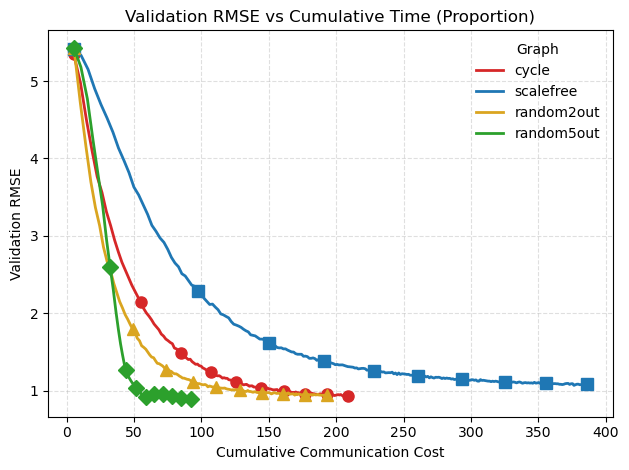

In [8]:
method = "userprop"

for graph in graphs[:3]:
    df_rmse = table_rmse[graph]
    df_time = table_time[graph]
    r = df_rmse[df_rmse["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
    c = df_time[df_time["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
    L = min(len(r), len(c))
    r, c = r[:L], c[:L]
    cc = np.cumsum(c)
    
    style = style_map[graph]
    idx = np.linspace(0, L - 1, 10, dtype=int)
    plt.plot(cc, r, label=graph, color=style["color"], linewidth=2)
    plt.plot(cc[idx], r[idx], linestyle='None', marker=style["marker"],
             color=style["color"], markersize=8)

graph = graphs[3]
df_rmse = table_rmse[graph]
df_time  = table_time[graph]
r = df_rmse[df_rmse["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
c = df_time[df_time["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
L = 65 #min(len(r), len(c))
r, c = r[:L], c[:L]
cc = np.cumsum(c)

style = style_map[graph]
idx = np.linspace(0, L - 1, 10, dtype=int)
plt.plot(cc, r, label=graph, color=style["color"], linewidth=2)
plt.plot(cc[idx], r[idx], linestyle='None', marker=style["marker"],
         color=style["color"], markersize=8)


plt.xlabel("Cumulative Communication Cost")
plt.ylabel("Validation RMSE")
plt.title("Validation RMSE vs Cumulative Time (Proportion)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Graph", frameon=False)
plt.tight_layout()
plt.savefig("scheme_prop.png", dpi=300)
plt.show()

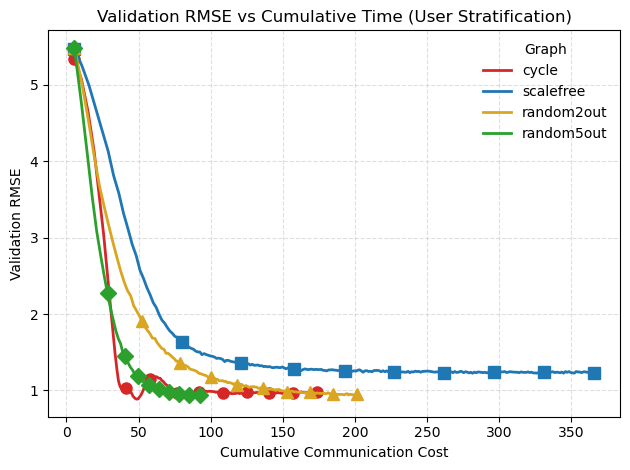

In [9]:
method = "urs"

for graph in graphs[:3]:
    df_rmse = table_rmse[graph]
    df_time = table_time[graph]
    r = df_rmse[df_rmse["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
    c = df_time[df_time["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
    L = min(len(r), len(c))
    r, c = r[:L], c[:L]
    cc = np.cumsum(c)
    
    style = style_map[graph]
    idx = np.linspace(0, L - 1, 10, dtype=int)
    plt.plot(cc, r, label=graph, color=style["color"], linewidth=2)
    plt.plot(cc[idx], r[idx], linestyle='None', marker=style["marker"],
             color=style["color"], markersize=8)

graph = graphs[3]
df_rmse = table_rmse[graph]
df_time = table_time[graph]
r = df_rmse[df_rmse["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
c = df_time[df_time["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
L = 65 #min(len(r), len(c))
r, c = r[:L], c[:L]
cc = np.cumsum(c)

style = style_map[graph]
idx = np.linspace(0, L - 1, 10, dtype=int)
plt.plot(cc, r, label=graph, color=style["color"], linewidth=2)
plt.plot(cc[idx], r[idx], linestyle='None', marker=style["marker"],
         color=style["color"], markersize=8)

plt.xlabel("Cumulative Communication Cost")
plt.ylabel("Validation RMSE")
plt.title("Validation RMSE vs Cumulative Time (User Stratification)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Graph", frameon=False)
plt.tight_layout()
plt.savefig("scheme_urs.png", dpi=300)
plt.show()

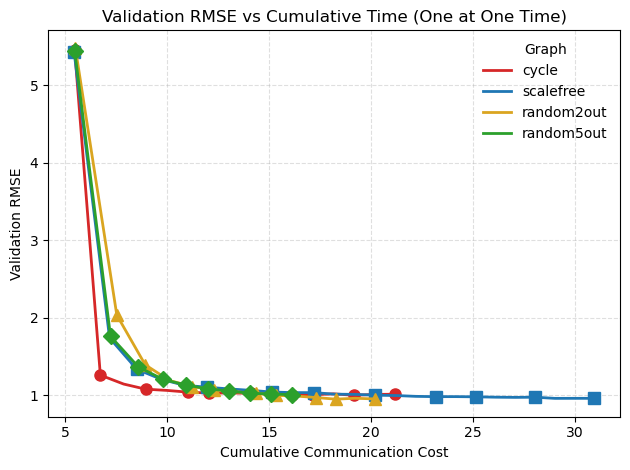

In [10]:
method = "oaat"

for graph in graphs[:3]:
    df_rmse = table_rmse[graph]
    df_time = table_time[graph]
    r = df_rmse[df_rmse["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
    c = df_time[df_time["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
    L = min(len(r), len(c))
    r, c = r[:L], c[:L]
    cc = np.cumsum(c)
    
    style = style_map[graph]
    idx = np.linspace(0, L - 1, 10, dtype=int)
    plt.plot(cc, r, label=graph, color=style["color"], linewidth=2)
    plt.plot(cc[idx], r[idx], linestyle='None', marker=style["marker"],
             color=style["color"], markersize=8)

graph = graphs[3]
df_rmse = table_rmse[graph]
df_time = table_time[graph]
r = df_rmse[df_rmse["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
c = df_time[df_time["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
L = 10#min(len(r), len(c))
r, c = r[:L], c[:L]
cc = np.cumsum(c)

style = style_map[graph]
idx = np.linspace(0, L - 1, 10, dtype=int)
plt.plot(cc, r, label=graph, color=style["color"], linewidth=2)
plt.plot(cc[idx], r[idx], linestyle='None', marker=style["marker"],
         color=style["color"], markersize=8)


plt.xlabel("Cumulative Communication Cost")
plt.ylabel("Validation RMSE")
plt.title("Validation RMSE vs Cumulative Time (One at One Time)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Graph", frameon=False)
plt.tight_layout()
plt.savefig("scheme_oaat.png", dpi=300)
plt.show()

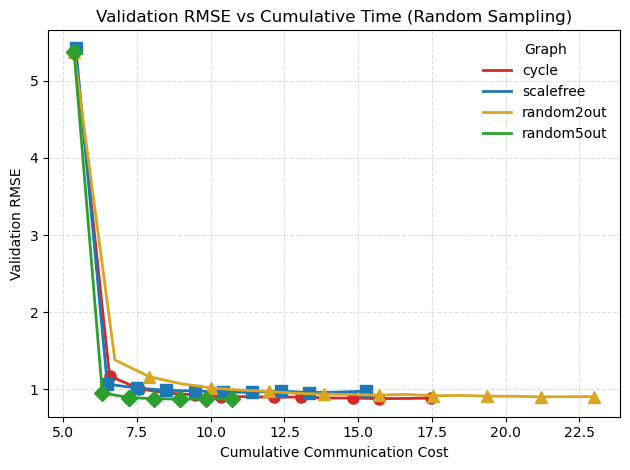

In [11]:
method = "rs"

for graph in graphs[:4]:
    df_rmse = table_rmse[graph]
    df_time = table_time[graph]
    r = df_rmse[df_rmse["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
    c = df_time[df_time["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
    L = min(len(r), len(c))
    r, c = r[:L], c[:L]
    cc = np.cumsum(c)
    
    style = style_map[graph]
    idx = np.linspace(0, L - 1, 10, dtype=int)
    plt.plot(cc, r, label=graph, color=style["color"], linewidth=2)
    plt.plot(cc[idx], r[idx], linestyle='None', marker=style["marker"],
             color=style["color"], markersize=8)


plt.xlabel("Cumulative Communication Cost")
plt.ylabel("Validation RMSE")
plt.title("Validation RMSE vs Cumulative Time (Random Sampling)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Graph", frameon=False)
plt.tight_layout()
plt.savefig("scheme_rs.png", dpi=300)
plt.show()